In [1]:
from pathlib import Path
import itertools
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import revpref as rp
from matplotlib.colors import to_rgba
from scipy import stats
from scipy.stats import spearmanr, ttest_ind, ttest_rel

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "Raw Data"
RESULTS_DIR = PROJECT_DIR / "Results"
RESULTS_DIR.mkdir(exist_ok=True)

df_1 = pd.read_excel(RAW_DIR / "301-decision-0628.xlsx")
df_2 = pd.read_excel(RAW_DIR / "301-questionnaire-0628.xlsx")
df = df_1.merge(df_2, on="Prolific ID", how="inner")


## Overall

### Task Share

In [2]:
def get_values1(row, prefix):
    cols = [f'{prefix} {i}' for i in range(1, 23)]
    return row[cols].values
def get_values2(row, prefix):
    cols = [f'{prefix} {i}' for i in range(23, 45)]
    return row[cols].values
def get_values3(row, prefix):
    cols = [f'{prefix} {i}' for i in range(45, 67)]
    return row[cols].values
df['px1'] = df.apply(lambda row: get_values1(row, 'X Revenue'), axis=1)
df['py1'] = df.apply(lambda row: get_values1(row, 'Y Revenue'), axis=1)
df['task_x1'] = df.apply(lambda row: get_values1(row, 'X Task'), axis=1)
df['task_y1'] = df.apply(lambda row: get_values1(row, 'Y Task'), axis=1)
df['qx1']=df['px1']* df['task_x1']
df['qy1']=df['py1']* df['task_y1']
df['px2'] = df.apply(lambda row: get_values2(row, 'X Revenue'), axis=1)
df['py2'] = df.apply(lambda row: get_values2(row, 'Y Revenue'), axis=1)
df['task_x2'] = df.apply(lambda row: get_values2(row, 'X Task'), axis=1)
df['task_y2'] = df.apply(lambda row: get_values2(row, 'Y Task'), axis=1)
df['qx2']=df['px2']* df['task_x2']
df['qy2']=df['py2']* df['task_y2']
df['px3'] = df.apply(lambda row: get_values3(row, 'X Revenue'), axis=1)
df['py3'] = df.apply(lambda row: get_values3(row, 'Y Revenue'), axis=1)
df['task_x3'] = df.apply(lambda row: get_values3(row, 'X Task'), axis=1)
df['task_y3'] = df.apply(lambda row: get_values3(row, 'Y Task'), axis=1)
df['qx3']=df['px3']* df['task_x3']
df['qy3']=df['py3']* df['task_y3']
df['task_share1'] = df['task_y1'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share2'] = df['task_y2'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share3'] = df['task_y3'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df[['task_share1','task_share2','task_share3']].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
task_share1,301.0,49.769,2.905,34.227,49.091,50.000,50.545,59.091
task_share2,301.0,48.338,10.543,0.000,46.091,49.818,51.091,99.000
task_share3,301.0,47.322,9.928,0.000,45.455,49.636,50.773,94.545


In [3]:
results = []
for col in ['task_share1', 'task_share2', 'task_share3']:
    x = df[col].dropna()                        # Drop missing values
    res = pg.ttest(x, 50, confidence=0.95)      # One-sample t-test against 50
    bf10 = float(res['BF10'].iloc[0])           # Convert BF10 to float if needed
    bf01 = 1.0 / bf10                           # BF01 measures evidence for the null mean of 50
    # Find the confidence-interval column across Pingouin versions
    ci_col = [c for c in res.columns if c.startswith('CI')][0]
    ci_low, ci_high = res[ci_col].iloc[0]
    results.append({
        'variable': col,
        'n': len(x),
        'mean': x.mean(),
        't': res['T'].iloc[0],
        'dof': res['dof'].iloc[0],
        'p_val': res['p_val'].iloc[0],
        'ci_low': ci_low,
        'ci_high': ci_high,
        'cohen_d': res['cohen_d'].iloc[0],
        'BF10': bf10,
        'BF01': bf01
    })
results_df = pd.DataFrame(results).round(2)
print(results_df)


      variable    n   mean     t  dof  p_val  ci_low  ci_high  cohen_d  \
0  task_share1  301  49.77 -1.38  300   0.17   49.44    50.10     0.08   
1  task_share2  301  48.34 -2.73  300   0.01   47.14    49.53     0.16   
2  task_share3  301  47.32 -4.68  300   0.00   46.20    48.45     0.27   

      BF10  BF01  
0     0.16  6.06  
1     2.51  0.40  
2  2291.33  0.00  


In [4]:
results = []
cols = ['task_share1', 'task_share2', 'task_share3']
for col1, col2 in combinations(cols, 2):
    # Drop rows missing either paired value
    paired = df[[col1, col2]].dropna()
    x = paired[col1]
    y = paired[col2]
    n = len(paired)
    diff = x - y
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(n)
    # paired t-test
    t_stat, p_value = stats.ttest_rel(x, y)
    # 95% confidence interval
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci_lower = mean_diff - t_crit * se_diff
    ci_upper = mean_diff + t_crit * se_diff
    results.append({
        'pair': f'{col1} vs {col2}',
        'n': n,
        'mean_diff': mean_diff,
        't_stat': t_stat,
        'p_value': p_value,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    })
results_df = pd.DataFrame(results)
print(results_df.round(3))


                         pair    n  mean_diff  t_stat  p_value  ci_lower  \
0  task_share1 vs task_share2  301      1.431   2.302    0.022     0.208   
1  task_share1 vs task_share3  301      2.448   4.145    0.000     1.286   
2  task_share2 vs task_share3  301      1.016   3.107    0.002     0.373   

   ci_upper  
0     2.655  
1     3.610  
2     1.660  


### Effect Size

In [5]:
x2=(df["task_share1"].mean()-df["task_share2"].mean())/df["task_share1"].std()
x2

0.49274837469799415

In [6]:
x3=(df["task_share3"].mean()-df["task_share1"].mean())/df["task_share1"].std()
x3

-0.8426839423380257

### Fig.2(a)

Paired t-test results:
$H\text{-}H$ vs $H\text{-}GPT$: t=2.3, p=0.0220 *
$H\text{-}H$ vs $H\text{-}DS$: t=4.1, p=0.0000 ***
$H\text{-}GPT$ vs $H\text{-}DS$: t=3.1, p=0.0021 **


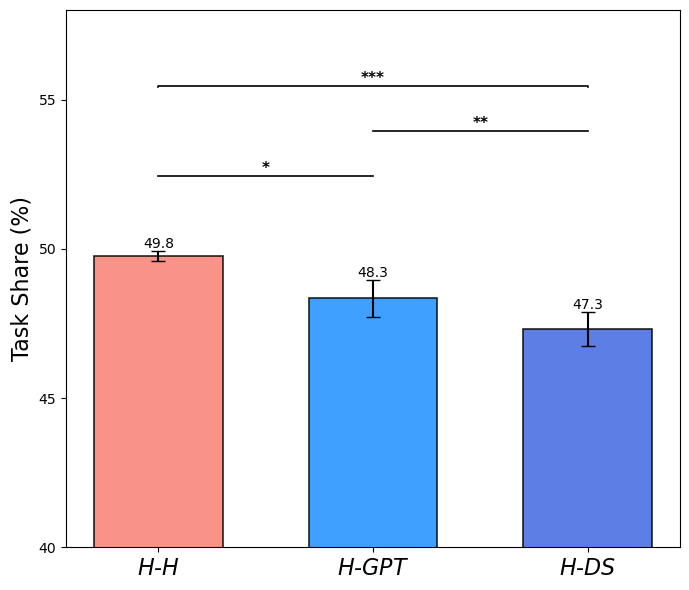

In [7]:
# Compute task-share variables
df['task_share1'] = df['task_y1'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share2'] = df['task_y2'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
df['task_share3'] = df['task_y3'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)
# Prepare data
variables = ['task_share1', 'task_share2', 'task_share3']
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors =['salmon', "dodgerblue", 'royalblue']
# Compute means and standard errors
means = [df[var].mean() for var in variables]
sems = [df[var].sem() for var in variables]
# Run paired t-tests and flag significance
def get_significance(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''
# Store significant pairwise comparisons
significant_pairs = []
print("=" * 60)
print("Paired t-test results:")
print("=" * 60)
for i, j in combinations(range(3), 2):
    data1 = df[variables[i]].dropna()
    data2 = df[variables[j]].dropna()
    t_stat, p_value = stats.ttest_rel(data1, data2, nan_policy='omit')
    sig = get_significance(p_value)
    print(f"{labels[i]} vs {labels[j]}: t={t_stat:.1f}, p={p_value:.4f} {sig}")
    if sig:  # Keep significant comparisons only
        significant_pairs.append((i, j, sig, p_value))
print("=" * 60)
# Create figure
fig, ax = plt.subplots(figsize=(7, 6))
# Draw the bar chart
x_pos = np.arange(len(variables))
bars = ax.bar(x_pos, means, yerr=sems, capsize=5, color=colors, 
              edgecolor='black', linewidth=1.2, alpha=0.85, width=0.6)
# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylabel('Task Share (%)', fontsize=16)
# Define a helper for significance brackets
def add_significance_line(ax, x1, x2, y, sig, h=0.01, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
# Set the initial bracket height
max_height = max([m + s for m, s in zip(means, sems)])
y_offset = max_height * 0.05
# Sort brackets by distance so shorter brackets appear lower
significant_pairs_sorted = sorted(significant_pairs, key=lambda x: x[1] - x[0])
# Draw significance brackets
current_y = max_height + y_offset
for i, j, sig, p_val in significant_pairs_sorted:
    add_significance_line(ax, x_pos[i], x_pos[j], current_y, sig)
    current_y += max_height * 0.03
# Set y-axis limits
ax.set_ylim(40, 58)
# Set y-axis limits
ax.set_yticks([40,45, 50, 55])
# Add grid lines
##ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
# Add mean labels above bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i], 
            f'{mean:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Fig.2(a).pdf", dpi=300, bbox_inches='tight')
plt.show()


### Fig.2(b)

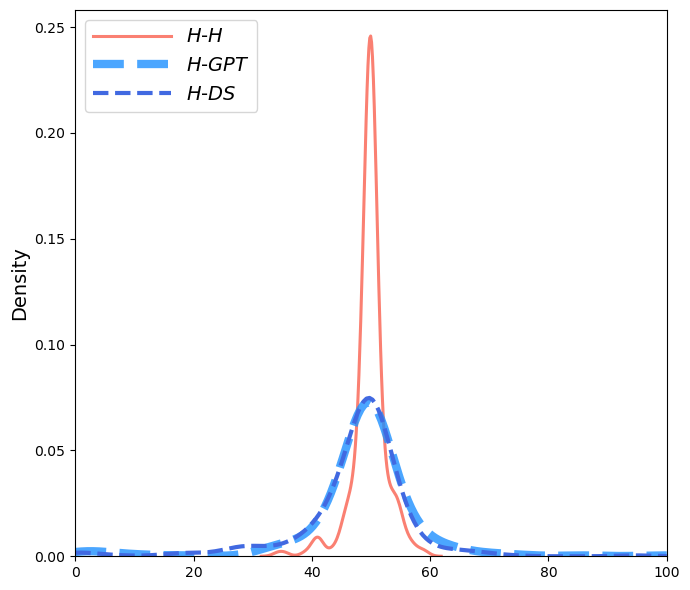

In [8]:
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors = ['salmon', 'dodgerblue', 'royalblue']
# colors = ['salmon', 'deepskyblue', sns.color_palette('Blues', 5)[3]]
cols = ['task_share1', 'task_share2', 'task_share3']
linewidths =  [2.2,6, 3]
linestyles = ['-', '--', '--']
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
for c, lab, col, lw, ls, alpha in zip(cols, labels, colors, linewidths, linestyles, [1, 0.8, 1]):
    x = pd.to_numeric(df[c], errors='coerce').dropna()
    sns.kdeplot(
        x=x, ax=ax,
        label=lab, color=col,
        lw=lw, linestyle=ls,
        fill=False, alpha=alpha,
        clip=(0, 100)
    )
ax.set_xlabel(None)
ax.set_ylabel('Density', fontsize=14)
ax.set_xlim(0, 100)
ax.legend(loc='upper left', fontsize=14,handlelength=4)
ax.grid(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Fig.2(b).pdf")
plt.show()


## Payoff-Maximizing Behavior

In [9]:
# ---------- 1. Define output column names ----------
gen_cols = []
for i in range(1, 67):
    gen_cols += [f"Revenue Max {i}", f"Revenue Min {i}", f"Revenue {i}", f"ratio {i}"]
gen_cols += ["loss_ratio_1", "loss_ratio_2", "loss_ratio_3"]
# ---------- 2. Drop existing columns for a clean rerun ----------
df = df.drop(columns=[c for c in gen_cols if c in df.columns])
# ---------- 3. Compute once and concatenate to avoid fragmentation ----------
new_cols = {}
for i in range(1, 67):
    x_rev  = df[f"X Revenue {i}"]
    y_rev  = df[f"Y Revenue {i}"]
    x_task = df[f"X Task {i}"]
    y_task = df[f"Y Task {i}"]
    rev_max = np.maximum(x_rev, y_rev) * 100
    rev_min = np.minimum(x_rev, y_rev) * 100
    rev_i   = x_rev * x_task + y_rev * y_task
    denom = rev_max - rev_min
    ratio = ((rev_max - rev_i) / denom).where(denom.ne(0), np.nan)
    new_cols[f"Revenue Max {i}"] = rev_max
    new_cols[f"Revenue Min {i}"] = rev_min
    new_cols[f"Revenue {i}"]     = rev_i
    new_cols[f"ratio {i}"]       = ratio
tmp = pd.DataFrame(new_cols, index=df.index)
tmp["loss_ratio_1"] = tmp[[f"ratio {i}" for i in range(1, 23)]].sum(axis=1, skipna=True) / 20
tmp["loss_ratio_2"] = tmp[[f"ratio {i}" for i in range(23, 45)]].sum(axis=1, skipna=True) / 20
tmp["loss_ratio_3"] = tmp[[f"ratio {i}" for i in range(45, 67)]].sum(axis=1, skipna=True) / 20
df = pd.concat([df, tmp], axis=1)
df[["loss_ratio_1", "loss_ratio_2", "loss_ratio_3"]].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
loss_ratio_1,301.0,0.215,0.156,0.0,0.090,0.214,0.325,0.658
loss_ratio_2,301.0,0.214,0.160,0.0,0.062,0.216,0.325,0.668
loss_ratio_3,301.0,0.216,0.164,0.0,0.059,0.215,0.326,0.686


### Loss Comparsion

In [10]:
cols = ["loss_ratio_1", "loss_ratio_2", "loss_ratio_3"]
results = []
for c1, c2 in combinations(cols, 2):
    paired = df[[c1, c2]].dropna()
    res = stats.ttest_rel(paired[c1], paired[c2])
    ci = res.confidence_interval(confidence_level=0.95)  # scipy >= 1.10
    results.append({
        "Comparison": f"{c1} vs {c2}",
        "Mean difference": (paired[c1] - paired[c2]).mean(),
        "t-statistic": res.statistic,
        "p-value": res.pvalue,
        "95% CI lower": ci.low,
        "95% CI upper": ci.high,
        "N": len(paired)
    })
result_df = pd.DataFrame(results)
print(result_df.round(3))


                     Comparison  Mean difference  t-statistic  p-value  \
0  loss_ratio_1 vs loss_ratio_2            0.001        0.151    0.880   
1  loss_ratio_1 vs loss_ratio_3           -0.001       -0.109    0.913   
2  loss_ratio_2 vs loss_ratio_3           -0.001       -0.329    0.742   

   95% CI lower  95% CI upper    N  
0        -0.010         0.012  301  
1        -0.012         0.010  301  
2        -0.010         0.007  301  


In [11]:
cols = ["loss_ratio_1", "loss_ratio_2", "loss_ratio_3"]
def get(tt, *names):
    """Return the first available candidate column"""
    for name in names:
        if name in tt.columns:
            return tt[name].iloc[0]
    raise KeyError(names)
results = []
for a, b in combinations(cols, 2):
    d = df[[a, b]].dropna()
    tt = pg.ttest(d[a], d[b], paired=True)
    bf10 = float(get(tt, "BF10", "bf10"))
    results.append({
        "pair":      f"{a} vs {b}",
        "n":         len(d),
        "mean_diff": (d[a] - d[b]).mean(),
        "t":         get(tt, "T", "t"),
        "p":         get(tt, "p-val", "p_val", "pval"),
        "BF10":      bf10,
        "BF01":      1 / bf10,
    })
res = pd.DataFrame(results).round(3)
print(res)


                           pair    n  mean_diff      t      p   BF10    BF01
0  loss_ratio_1 vs loss_ratio_2  301      0.001  0.151  0.880  0.065  15.385
1  loss_ratio_1 vs loss_ratio_3  301     -0.001 -0.109  0.913  0.065  15.385
2  loss_ratio_2 vs loss_ratio_3  301     -0.001 -0.329  0.742  0.068  14.706


### Extended Data Fig.1(a)

In [12]:
# Define base indices
group_A = [2, 8, 10, 12, 13, 14, 16, 18, 20, 22] 
group_B = [1, 3, 4, 6, 9, 11, 15, 17, 19, 21]   
# Define offsets
offsets = [0, 22, 44]
# Create summary columns
for idx, offset in enumerate(offsets, start=1):
    # Group A
    cols_A = [f"ratio {i + offset}" for i in group_A]
    df[f"ratio_sum_A{idx}"] = df[cols_A].mean(axis=1, skipna=True)
    # Group B
    cols_B = [f"ratio {i + offset}" for i in group_B]
    df[f"ratio_sum_B{idx}"] = df[cols_B].mean(axis=1, skipna=True)

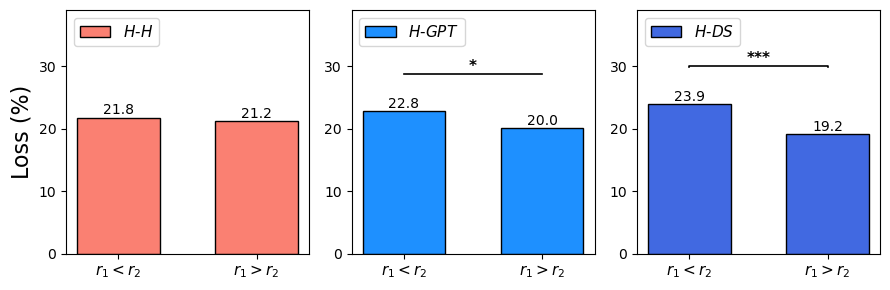

ratio_sum_A1 vs ratio_sum_B1: t = 1.567, p = 0.118
ratio_sum_A2 vs ratio_sum_B2: t = 2.334, p = 0.0203
ratio_sum_A3 vs ratio_sum_B3: t = 4.255, p = 2.8e-05


In [13]:
def add_significance_line(ax, x1, x2, y, sig, h=0.02, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom',
            fontsize=11, fontweight='bold')
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors = ['salmon', 'dodgerblue', 'royalblue']
bar_labels_list = [
    [r'$r_1 < r_2$', r'$r_1 > r_2$'],
    [r'$r_1 < r_2$', r'$r_1 > r_2$'],
    [r'$r_1 < r_2$', r'$r_1 > r_2$']
]
means_A = [df[f"ratio_sum_A{i}"].mean()*100 for i in range(1, 4)]
means_B = [df[f"ratio_sum_B{i}"].mean()*100 for i in range(1, 4)]
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
# Store paired t-test results
ttest_results = []
for idx in range(3):
    ax = axes[idx]
    colA = f"ratio_sum_A{idx+1}"
    colB = f"ratio_sum_B{idx+1}"
    # Run paired t-tests after dropping missing values
    a_vals = df[colA].values
    b_vals = df[colB].values
    # Drop missing values after pairing
    paired = np.vstack([a_vals, b_vals]).T
    paired = paired[~np.isnan(paired).any(axis=1)]
    a_clean = paired[:, 0]
    b_clean = paired[:, 1]
    t_stat, p_val = ttest_rel(a_clean, b_clean)
    ttest_results.append((colA, colB, t_stat, p_val))
    # Bar heights
    values = [means_A[idx], means_B[idx]]
    x_pos = [0, 1]
    # Draw bars and add legend labels
    bars = ax.bar(x_pos, values, color=[colors[idx], colors[idx]],
                  edgecolor='black', width=0.6, label=labels[idx])
    ax.legend(loc='upper left', fontsize=11, frameon=True)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels_list[idx], fontsize=11)
    # Show the y-axis label only on the first panel
    if idx == 0:
        ax.set_ylabel('Loss (%)', fontsize=16)
    # Show values on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    # Create significance labels from p-values
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = ''
    ax.set_ylim(0, 39)
    ax.set_yticks(np.arange(0, 40, 10))
    # Draw brackets only for significant tests and adjust positions dynamically
    if sig:
        max_bar_height = max(values)
        offset = 6
        y_line = max_bar_height + offset
        add_significance_line(ax, x_pos[0], x_pos[1], y_line, sig, h=0.02)
    # Add grid lines
    ###ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.1(a).pdf", dpi=300, bbox_inches='tight')
plt.show()
# Print paired t-test results
for colA, colB, t_stat, p_val in ttest_results:
    print(f"{colA} vs {colB}: t = {t_stat:.3f}, p = {p_val:.3g}")


### Extended Data Fig.1(b)

In [14]:
# Define base indices
group_A = [1, 3, 4, 6, 9, 11, 15, 17, 19, 21]
group_B = [2, 8, 10, 12, 13, 14, 16, 18, 20, 22]
# Define offsets
offsets = [0, 22, 44]
all_indices = set()
for base_group in [group_A, group_B]:
    for offset in offsets:
        for i in base_group:
            all_indices.add(i + offset)
for i in all_indices:
    tx = f"X Task {i}"
    ty = f"Y Task {i}"
    xr = f"X Revenue {i}"
    yr = f"Y Revenue {i}"
    out = f"Corner {i}"
    df[out] = np.where(
        ((df[tx]>= 100) & (df[xr] > df[yr])) |
        ((df[ty] >= 100) & (df[yr] > df[xr])),
        1, 0
    ).astype(int)
# Create summary columns
for idx, offset in enumerate(offsets, start=1):
    # Group A
    cols_A = [f"Corner {i + offset}" for i in group_A]
    df[f"Corner_sum_A{idx}"] = df[cols_A].mean(axis=1, skipna=True)
    # Group B
    cols_B = [f"Corner {i + offset}" for i in group_B]
    df[f"Corner_sum_B{idx}"] = df[cols_B].mean(axis=1, skipna=True)

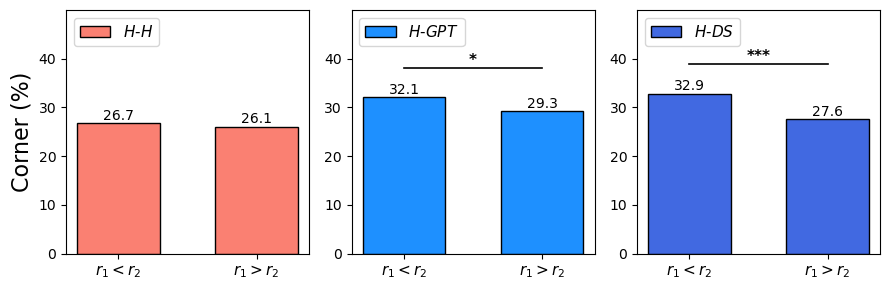

Corner_sum_A1 vs Corner_sum_B1: t = 1.547, p = 0.123
Corner_sum_A2 vs Corner_sum_B2: t = 2.247, p = 0.02535
Corner_sum_A3 vs Corner_sum_B3: t = 4.137, p = 4.566e-05


In [15]:
def add_significance_line(ax, x1, x2, y, sig, h=0.02, lw=1.2):
    """Add a significance bracket between two bars"""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='black')
    ax.text((x1+x2)/2, y+h, sig, ha='center', va='bottom',
            fontsize=11, fontweight='bold')
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors = ['salmon', 'dodgerblue', 'royalblue']
bar_labels_list = [
    [r'$r_1 < r_2$', r'$r_1 > r_2$'],
    [r'$r_1 < r_2$', r'$r_1 > r_2$'],
    [r'$r_1 < r_2$', r'$r_1 > r_2$']
]
means_A = [df[f"Corner_sum_A{i}"].mean()*100 for i in range(1, 4)]
means_B = [df[f"Corner_sum_B{i}"].mean()*100 for i in range(1, 4)]
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
# Store paired t-test results
ttest_results = []
for idx in range(3):
    ax = axes[idx]
    colA = f"Corner_sum_A{idx+1}"
    colB = f"Corner_sum_B{idx+1}"
    # Run paired t-tests after dropping missing values
    a_vals = df[colA].values
    b_vals = df[colB].values
    # Drop missing values after pairing
    paired = np.vstack([a_vals, b_vals]).T
    paired = paired[~np.isnan(paired).any(axis=1)]
    a_clean = paired[:, 0]
    b_clean = paired[:, 1]
    t_stat, p_val = ttest_rel(a_clean, b_clean)
    ttest_results.append((colA, colB, t_stat, p_val))
    # Bar heights
    values = [means_A[idx], means_B[idx]]
    x_pos = [0, 1]
    # Draw bars and add legend labels
    bars = ax.bar(x_pos, values, color=[colors[idx], colors[idx]],
                  edgecolor='black', width=0.6, label=labels[idx])
    ax.legend(loc='upper left', fontsize=11, frameon=True)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(bar_labels_list[idx], fontsize=11)
    # Set the y-axis label only on the first panel
    if idx == 0:
        ax.set_ylabel('Corner (%)', fontsize=16)
    # Show values on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    # Create significance labels from p-values
    if p_val < 0.001:
        sig = '***'
    elif p_val < 0.01:
        sig = '**'
    elif p_val < 0.05:
        sig = '*'
    else:
        sig = ''
    ax.set_ylim(0, 50)
    ax.set_yticks(np.arange(0, 50, 10))
    # Add grid lines
    ###ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    # Draw brackets only for significant tests and adjust positions dynamically
    if sig:
        max_bar_height = max(values)
        offset = 6
        y_line = max_bar_height + offset
        add_significance_line(ax, x_pos[0], x_pos[1], y_line, sig, h=0.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.1(b).pdf", dpi=300, bbox_inches='tight')
plt.show()
# Print paired t-test results
for colA, colB, t_stat, p_val in ttest_results:
    print(f"{colA} vs {colB}: t = {t_stat:.3f}, p = {p_val:.4g}")


## Decision-Making Quality

### Compute CCEI

In [16]:
# Combine px1 and py1 into a 2x22 array
# Combine px1 and py1 into arrays and concatenate
df['p1'] = df.apply(lambda row: 
    np.array([row['px1'], row['py1']]) , axis=1)
df['q1'] = df.apply(lambda row: 
    np.array([row['qx1'], row['qy1']]) , axis=1)
df['p2'] = df.apply(lambda row: 
    np.array([row['px2'], row['py2']]) , axis=1)
df['q2'] = df.apply(lambda row: 
    np.array([row['qx2'], row['qy2']]) , axis=1)
df['p3'] = df.apply(lambda row: 
    np.array([row['px3'], row['py3']]) , axis=1)
df['q3'] = df.apply(lambda row: 
    np.array([row['qx3'], row['qy3']]) , axis=1)
def compute_ccei(p, q, *, invert_p=True):
    """
    Compute the CCEI for given p and q.
    Parameters
    ----------
    p, q : array-like
        Accept numpy arrays, lists, pandas Series, or ndarrays stored in cells.
        Accept common shapes and coerce them to 2D.
    invert_p : bool
        Whether to transform p as 1/p.
    Returns
    -------
    float
        CCEI value; returns np.nan on failure.
    """
    try:
        p = np.asarray(p)
        q = np.asarray(q)
        if invert_p:
            p = 1.0 / p
        # Transpose to keep the original calculation convention
        p = p.T
        q = q.T
        # revpref typically expects a 2D goods-by-observations structure
        if p.ndim == 1:
            p = p.reshape(-1, 1)
        if q.ndim == 1:
            q = q.reshape(-1, 1)
        pref = rp.RevealedPreference(p, q)
        return pref.ccei()
    except Exception as e:
        print(f"Error while computing CCEI: {e}")
        return np.nan
df["ccei1"] = df.apply(lambda r: compute_ccei(r["p1"], r["q1"]), axis=1)
df["ccei2"] = df.apply(lambda r: compute_ccei(r["p2"], r["q2"]), axis=1)
df["ccei3"] = df.apply(lambda r: compute_ccei(r["p3"], r["q3"]), axis=1)
df[["ccei1", "ccei2", "ccei3"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ccei1,301.0,0.947,0.134,0.25,0.988,1.0,1.0,1.0
ccei2,301.0,0.955,0.117,0.25,0.983,1.0,1.0,1.0
ccei3,301.0,0.948,0.131,0.25,0.987,1.0,1.0,1.0


### CCEI Comparsion

In [17]:
results = []
pairs = combinations(["ccei1", "ccei2", "ccei3"], 2)
for var1, var2 in pairs:
    sub = df[[var1, var2]].dropna()
    x, y = sub[var1], sub[var2]
    diff = x - y
    n = len(diff)
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(n)
    # paired t-test
    t_stat, p_val = stats.ttest_rel(x, y)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff
    results.append({
        "pair": f"{var1} vs {var2}",
        "N": n,
        "mean_diff": mean_diff,
        "t": t_stat,
        "p": p_val,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
    })
res_df = pd.DataFrame(results)
print(res_df.round(3))


             pair    N  mean_diff      t      p  ci_95_low  ci_95_high
0  ccei1 vs ccei2  301     -0.008 -1.274  0.204     -0.020       0.004
1  ccei1 vs ccei3  301     -0.001 -0.168  0.867     -0.016       0.013
2  ccei2 vs ccei3  301      0.006  0.964  0.336     -0.007       0.020


In [18]:
cols = ["ccei1", "ccei2", "ccei3"]
label_map = {
    "ccei1": r"$H\text{-}H$",
    "ccei2": r"$H\text{-}GPT$",
    "ccei3": r"$H\text{-}DS$",
}
results = []
for c1, c2 in itertools.combinations(cols, 2):
    sub = df[[c1, c2]].dropna()
    x, y = sub[c1], sub[c2]
    res = pg.ttest(x, y, paired=True)
    bf10 = float(res["BF10"].iloc[0])
    bf01 = 1.0 / bf10
    results.append({
        "Comparison": f"{label_map[c1]} vs. {label_map[c2]}",
        "BF10":   round(bf10, 3),
        "BF01":   round(bf01, 3),
    })
res_df = pd.DataFrame(results)
print(res_df)


                         Comparison   BF10    BF01
0   $H\text{-}H$ vs. $H\text{-}GPT$  0.144   6.944
1    $H\text{-}H$ vs. $H\text{-}DS$  0.066  15.152
2  $H\text{-}GPT$ vs. $H\text{-}DS$  0.102   9.804


In [19]:
def simulate_ccei_for_row(df, row_idx, n_sim=1000, *, seed=None, invert_p=True):
    """
    For one row of df, simulate random q1 values
    compute CCEI n_sim times and return the mean.
    Parameters
    ----------
    df : DataFrame
    row_idx : Row index, either an integer position or a label.
    n_sim : Number of simulations.
    seed : Optional random seed.
    invert_p : Argument passed to compute_ccei.
    Returns
    -------
    mean_ccei : float
        Mean CCEI over n_sim simulations.
    all_ccei : ndarray
        Vector of CCEI values with length n_sim.
    """
    # Select the row
    row = df.loc[row_idx]
    # Extract p1 and q1
    p1 = np.asarray(row["p1"])
    q1 = np.asarray(row["q1"])
    rng = np.random.default_rng(seed)
    cceis = np.empty(n_sim, dtype=float)
    for i in range(n_sim):
        # Handle both 2x22 and 22x2 shapes
        if p1.shape == (2, 22):
            T = p1.shape[1]      # 22
            x = rng.uniform(0, 100, size=T)  # Uniform draw on [0, 100] with length 22
            random_q1 = np.empty_like(p1, dtype=float)
            # Each period： (x_t, 100-x_t) * (p1_good1_t, p1_good2_t)
            random_q1[0, :] = x * p1[0, :]
            random_q1[1, :] = (100 - x) * p1[1, :]
        elif p1.shape == (22, 2):
            T = p1.shape[0]      # 22
            x = rng.uniform(0, 100, size=T)
            random_q1 = np.empty_like(p1, dtype=float)
            random_q1[:, 0] = x * p1[:, 0]
            random_q1[:, 1] = (100 - x) * p1[:, 1]
        else:
            raise ValueError(f"Unsupported p1 shape: {p1.shape}; expected 2x22 or 22x2")
        # Pass simulated choices to the CCEI function
        cceis[i] = compute_ccei(p1, random_q1, invert_p=invert_p)
    return cceis.mean(), cceis
mean_ccei, all_cceis = simulate_ccei_for_row(df, row_idx=0, n_sim=1000, seed=123)
print("Mean simulated CCEI for this row under random q1:", mean_ccei)


Mean simulated CCEI for this row under random q1: 0.7126490436523776


### Extended Data Fig.2(a)

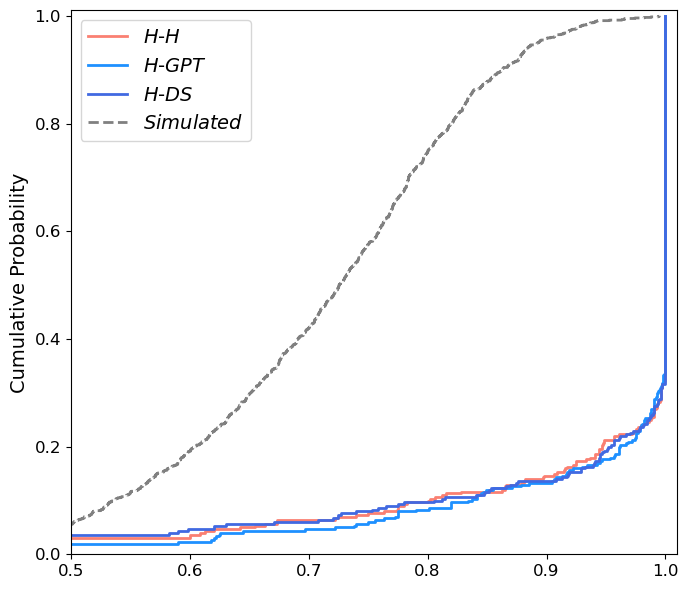

In [20]:
# Set labels and colors
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors = ['salmon', 'dodgerblue', 'royalblue']
ccei_cols = ['ccei1', 'ccei2', 'ccei3']
fig, ax = plt.subplots(figsize=(7, 6))
# Draw CDF curves
for col, label, color in zip(ccei_cols, labels, colors):
    data = df[col].dropna()
    sns.ecdfplot(data=data, ax=ax, label=label, color=color, linewidth=2)
sns.ecdfplot(
    data=all_cceis, ax=ax,
    label=r'$Simulated$', color='gray',
    linestyle='--', linewidth=2
)
# Set figure properties
ax.set_ylim(0, 1.01)
ax.set_xlabel(None)
ax.set_ylabel('Cumulative Probability', fontsize=14)
ax.legend(loc='upper left', fontsize=14)
ax.grid(False)
# Set tick-label font size
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(0.5, 1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.2(a).pdf")
plt.show()


In [21]:
threshold = 0.9
prop_over_09 = (
    df[["ccei1", "ccei2", "ccei3"]]  # Select CCEI columns
    .gt(threshold)                           
    .mean()                                
)
(prop_over_09 * 100).round(2)


ccei1    85.38
ccei2    86.71
ccei3    86.38
dtype: float64

### Extended Data Fig.3(a)

In [23]:
for i in range(1, 4):
    # Compute ln_price_ratio
    def calc_ln_price_ratio(row, idx=i):
        px = row[f'px{idx}'].astype(float)
        py = row[f'py{idx}'].astype(float)
        # Replace zeros in py with a small value
        py = np.where(py == 0, 0.1, py)
        px = np.where(px == 0, 0.1, px)
        return np.log(px / py)
    df[f'ln_price_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_price_ratio(row, idx), axis=1)
    # Compute ln_q_ratio
    def calc_ln_q_ratio(row, idx=i):
        px = row[f'px{idx}'].astype(float)
        py = row[f'py{idx}'].astype(float)
        task_x = row[f'task_x{idx}'].astype(float)
        task_y = row[f'task_y{idx}'].astype(float)
        # Replace zero task values with 0.1
        task_x = np.where(task_x == 0, 0.1, task_x)
        task_y = np.where(task_y == 0, 0.1, task_y)
        # Apply the same zero adjustment to revenue
        px = np.where(px == 0, 0.1, px)
        py = np.where(py == 0, 0.1, py)
        qx = px * task_x
        qy = py * task_y
        return np.log(qx / qy)
    df[f'ln_q_ratio{i}'] = df.apply(lambda row, idx=i: calc_ln_q_ratio(row, idx), axis=1)
def calc_spearman_corr(row, idx):
    ln_price = row[f'ln_price_ratio{idx}']
    ln_q = row[f'ln_q_ratio{idx}']
    # Ensure array format
    ln_price = np.array(ln_price).astype(float)
    ln_q = np.array(ln_q).astype(float)
    # Handle possible nan or inf values
    mask = np.isfinite(ln_price) & np.isfinite(ln_q)
    if mask.sum() < 2:  # Require at least two valid observations
        return np.nan
    corr, _ = spearmanr(ln_price[mask], ln_q[mask])
    return corr
# Compute Spearman correlations across measures
for i in range(1, 4):
    df[f'spearman_corr{i}'] = df.apply(lambda row, idx=i: calc_spearman_corr(row, idx), axis=1)


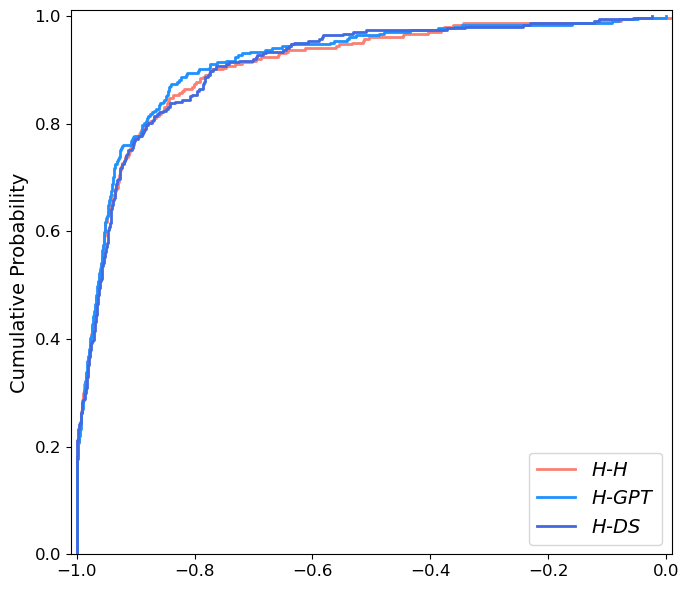

In [24]:
# Set labels and colors
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
colors = ['salmon', 'dodgerblue', 'royalblue']
ccei_cols = ['spearman_corr1', 'spearman_corr2', 'spearman_corr3']
fig, ax = plt.subplots(figsize=(7, 6))
# Draw CDF curves
for col, label, color in zip(ccei_cols, labels, colors):
    data = df[col].dropna()
    sns.ecdfplot(data=-data, ax=ax, label=label, color=color, linewidth=2)
# Set figure properties
ax.set_ylim(0, 1.01)
# Use double quotes for string labels
ax.set_xlabel(None)
ax.set_ylabel('Cumulative Probability', fontsize=14)
ax.legend(loc='lower right', fontsize=14)
ax.grid(False)
# Set tick-label font size
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-1.01, 0.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Extended Data Fig.3(a).pdf")
plt.show()


## Individual Heterogeneity

In [25]:
# Use double brackets to select multiple columns
cols = ["task_share1", "task_share2", "task_share3"]
data = df[cols].dropna()  # Drop missing values before F-tests
results = []
# ============ 1. Pairwise F-tests ============
for col1, col2 in combinations(cols, 2):
    x = data[col1]
    y = data[col2]
    var1, var2 = x.var(ddof=1), y.var(ddof=1)
    n1, n2 = len(x), len(y)
    # F-statistic with the larger variance in the numerator
    if var1 >= var2:
        F = var1 / var2
        dfn, dfd = n1 - 1, n2 - 1
    else:
        F = var2 / var1
        dfn, dfd = n2 - 1, n1 - 1
    # Two-sided p-value
    p_value = 2 * (1 - stats.f.cdf(F, dfn, dfd))
    p_value = min(p_value, 1.0)
    results.append({
        "Comparison": f"{col1} vs {col2}",
        "Variance 1": var1,
        "Variance 2": var2,
        "F-statistic": F,
        "p-value": p_value,
        "Significance": "***" if p_value < 0.01 else "**" if p_value < 0.05 else "*" if p_value < 0.1 else ""
    })
results_df = pd.DataFrame(results)
print("=" * 70)
print("Pairwise variance F-test results:")
print(results_df.round(4).to_string(index=False))
# ============ 2. Ratios relative to the standard deviation of task_share1 ============
sd_base = data["task_share1"].std(ddof=1)
sd_ratio = pd.DataFrame({
    "Variable": cols,
    "Standard deviation": [data[c].std(ddof=1) for c in cols],
    "Ratio to task_share1 SD": [data[c].std(ddof=1) / sd_base for c in cols]
})
print("=" * 70)
print("Standard-deviation ratios relative to task_share1:")
print(sd_ratio.round(4).to_string(index=False))


Pairwise variance F-test results:
                Comparison  Variance 1  Variance 2  F-statistic  p-value Significance
task_share1 vs task_share2      8.4373    111.1594      13.1747   0.0000          ***
task_share1 vs task_share3      8.4373     98.5614      11.6816   0.0000          ***
task_share2 vs task_share3    111.1594     98.5614       1.1278   0.2981             
Standard-deviation ratios relative to task_share1:
   Variable  Standard deviation  Ratio to task_share1 SD
task_share1              2.9047                   1.0000
task_share2             10.5432                   3.6297
task_share3              9.9278                   3.4178


In [26]:
df['task_share_type1'] = df['task_y1'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100
df['task_share_type2'] = df['task_y2'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100
df['task_share_type3'] = df['task_y3'].apply(
    lambda x: np.nanmean(x) if x is not None and len(x) else np.nan
)/100

### Fig.3

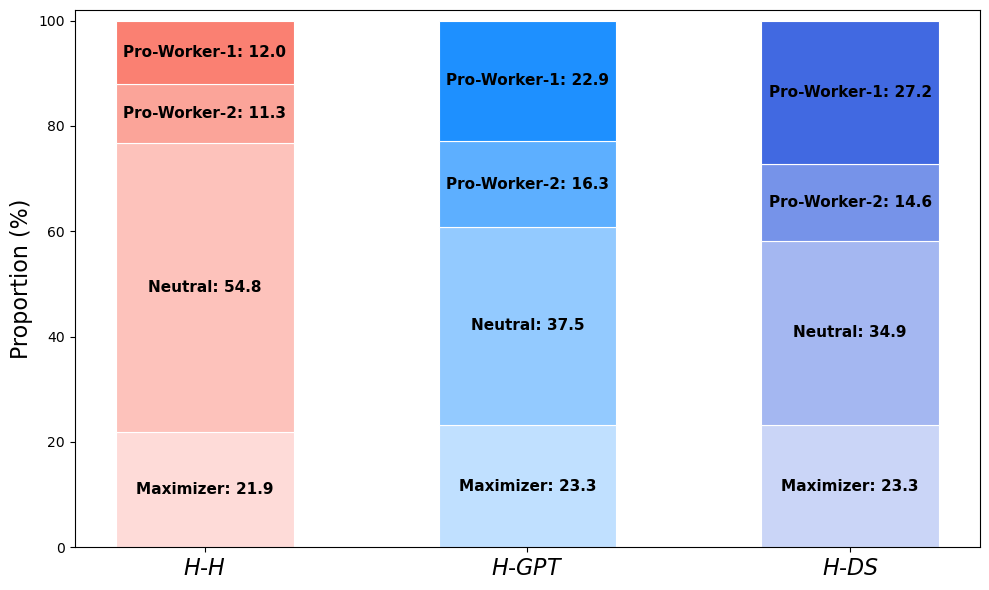

In [27]:
LOSS_CUT = 0.05
LOW, HIGH = 0.48, 0.52
cats = [
    "loss<0.05",
    "loss≥0.05 & 0.48≤share≤0.52",
    "loss≥0.05 & share>0.52",
    "loss≥0.05 & share<0.48",
]
cat_labels = ["Maximizer", "Neutral", "Pro-Worker-2", "Pro-Worker-1"]
def classify(loss, share):
    loss = pd.to_numeric(loss, errors="coerce")
    share = pd.to_numeric(share, errors="coerce")
    out = pd.Series(np.nan, index=loss.index, dtype="object")
    m_valid = loss.notna() & share.notna()
    m1 = m_valid & (loss <= LOSS_CUT)
    out[m1] = cats[0]
    m_ge = m_valid & (loss > LOSS_CUT)
    out[m_ge & (share < LOW)] = cats[3]
    out[m_ge & (share > HIGH)] = cats[2]
    out[m_ge & (share >= LOW) & (share <= HIGH)] = cats[1]
    return out
for i in [1, 2, 3]:
    df[f"type_{i}"] = classify(df[f"loss_ratio_{i}"], df[f"task_share_type{i}"])
prop = (
    pd.DataFrame({
        "H-H":   df["type_1"].value_counts(normalize=True),
        "H-GPT": df["type_2"].value_counts(normalize=True),
        "H-DS":  df["type_3"].value_counts(normalize=True),
    })
    .reindex(cats)
    .fillna(0.0)
)
# ── Color scheme: one base color per group with four shades ──
base_colors = ['salmon', 'dodgerblue', 'royalblue']  # H-H, H-GPT, H-DS
# Shade factors from dark to light for categories 0-3
alpha_levels = [0.28,0.48,0.72,1.0]
def make_shades(base, alphas):
    """Return shaded RGBA colors by blending a base color with white"""
    r, g, b, _ = to_rgba(base)
    shades = []
    for a in alphas:
        shades.append((r * a + 1 * (1 - a),
                       g * a + 1 * (1 - a),
                       b * a + 1 * (1 - a),
                       1.0))
    return shades
group_shades = [make_shades(bc, alpha_levels) for bc in base_colors]
labels = [r'$H\text{-}H$', r'$H\text{-}GPT$', r'$H\text{-}DS$']
# ── Draw figure ──
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(prop.shape[1])
bottom = np.zeros(prop.shape[1])
for k, cat in enumerate(cats):
    vals = prop.loc[cat].values * 100
    bar_colors = [group_shades[j][k] for j in range(len(x))]
    bars = ax.bar(x, vals, bottom=bottom, color=bar_colors, width=0.55,
                  edgecolor="white", linewidth=0.8)
    for j, (bar, v) in enumerate(zip(bars, vals)):
        cy = bottom[j] + v / 2
        ax.text(bar.get_x() + bar.get_width() / 2, cy,
                f"{cat_labels[k]}: {v:.1f}",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="black")
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=16)
ax.set_ylim(0, 102)
ax.set_ylabel("Proportion (%)", fontsize=16)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "Fig.3.pdf")
plt.show()


### IOS Comparsion

In [27]:
df['IOS_Human'] = df["Answer 1"].astype(int)
df['IOS_GPT'] = df["Answer 2"].astype(int)
df['IOS_DS'] = df["Answer 3"].astype(int)
df["diff_IOS_GPT"] =df["IOS_GPT"]- df["IOS_Human"] 
df["diff_IOS_DS"] =   df["IOS_DS"]-df["IOS_Human"]
df[["IOS_Human","IOS_GPT","IOS_DS"]].describe().T.round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/408453000.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IOS_Human'] = df["Answer 1"].astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/408453000.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['IOS_GPT'] = df["Answer 2"].astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/408453000.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

,count,mean,std,min,25%,50%,75%,max
IOS_Human,301.0,3.784,1.662,1.0,3.0,4.0,5.0,7.0
IOS_GPT,301.0,2.983,1.793,1.0,1.0,3.0,4.0,7.0
IOS_DS,301.0,2.525,1.634,1.0,1.0,2.0,4.0,7.0


In [28]:
pairs = [
    ("IOS_Human", "IOS_GPT"),
    ("IOS_Human", "IOS_DS"),
    ("IOS_GPT", "IOS_DS")
]
results = []
for var1, var2 in pairs:
    res = stats.ttest_rel(df[var1], df[var2])
    ci = res.confidence_interval(confidence_level=0.95)  # 95% CI
    mean_diff = (df[var1] - df[var2]).mean()
    results.append({
        "Pair": f"{var1} vs {var2}",
        "Mean Diff": round(mean_diff, 3),
        "t-statistic": round(res.statistic, 3),
        "p-value": res.pvalue,
        "95% CI Lower": round(ci.low, 3),
        "95% CI Upper": round(ci.high, 3)
    })
paired_t_test = pd.DataFrame(results)
print(paired_t_test)


                   Pair  Mean Diff  t-statistic       p-value  95% CI Lower  \
0  IOS_Human vs IOS_GPT      0.801        8.571  5.524687e-16         0.617   
1   IOS_Human vs IOS_DS      1.259       13.231  8.569606e-32         1.072   
2     IOS_GPT vs IOS_DS      0.458        7.214  4.462021e-12         0.333   

   95% CI Upper  
0         0.985  
1         1.446  
2         0.584  


## Regression Data

In [29]:
df['use AI at work'] = df['Answer 19'].map({'Yes': 1, 'No': 0})
df['use AI out of work'] = df['Answer 23'].map({'Yes': 1, 'No': 0})

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2766448031.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['use AI at work'] = df['Answer 19'].map({'Yes': 1, 'No': 0})
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2766448031.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['use AI out of work'] = df['Answer 23'].map({'Yes': 1, 'No': 0})


In [30]:
# Split Answer 22 and Answer 30 into four columns
df[['Answer 22_1', 'Answer 22_2', 'Answer 22_3']] = \
    df['Answer 22'].str.split(',', expand=True)
df[['Answer 26_1', 'Answer 26_2', 'Answer 26_3']] = \
    df['Answer 26'].str.split(',', expand=True)
# Mapping dictionary
mapping = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Somewhat disagree': 3,
    'Neutral': 4,
    'Somewhat agree': 5,
    'Agree': 6,
    'Strongly agree': 7
}
# Map values and fill missing values with 1
cols_22 = ['Answer 22_1', 'Answer 22_2', 'Answer 22_3']
cols_26 = ['Answer 26_1', 'Answer 26_2', 'Answer 26_3']
df[cols_22] = df[cols_22].apply(lambda s: s.map(mapping).fillna(1))
df[cols_26] = df[cols_26].apply(lambda s: s.map(mapping).fillna(1))
# Compute scores
df['Improvement_scores1'] = df[cols_22].sum(axis=1)
df['Improvement_scores2'] = df[cols_26].sum(axis=1)
df['Improvement_scores'] = (df['Improvement_scores1'] + df['Improvement_scores2']) / 2

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2497346610.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Answer 22_1', 'Answer 22_2', 'Answer 22_3']] = \
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2497346610.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Answer 22_1', 'Answer 22_2', 'Answer 22_3']] = \
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2497346610.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calli

In [31]:
# Answer 27 -> AI_days1
df["AI_days1"] = pd.to_numeric(df["Answer 20"], errors="coerce").fillna(0)
# Answer 31 -> AI_days2
df["AI_days2"] = pd.to_numeric(df["Answer 24"], errors="coerce").fillna(0)
df["AI_days_total"] = df["AI_days1"] + df["AI_days2"]

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/809590830.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AI_days1"] = pd.to_numeric(df["Answer 20"], errors="coerce").fillna(0)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/809590830.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AI_days2"] = pd.to_numeric(df["Answer 24"], errors="coerce").fillna(0)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/809590830.py:5: PerformanceWarning: DataFrame is highly fragmente

In [32]:
mapping = {
    '0-15 Minutes / Day': 1,
    '15-59 Minutes / Day': 2,
    '60+ Minutes / Day': 3
}
df["AI_hours1"] = df["Answer 21"].map(mapping).fillna(0).astype(int)
df["AI_hours2"] = df["Answer 25"].map(mapping).fillna(0).astype(int)
df["AI_hours_total"] = df["AI_hours1"] + df["AI_hours2"]

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2899260203.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AI_hours1"] = df["Answer 21"].map(mapping).fillna(0).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2899260203.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AI_hours2"] = df["Answer 25"].map(mapping).fillna(0).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2899260203.py:8: PerformanceWarning: DataFrame is highly fragmented.  This 

In [33]:
# 1. Identify columns to reshape
value_cols = [c for c in df.columns if re.match(r'.* (Task|Revenue) \d+$', c)]
ratio_cols = [c for c in df.columns if re.match(r'^ratio \d+$', c)]
corner_cols = [c for c in df.columns if re.match(r'^Corner \d+$', c)]
# 2. Process X/Y task and revenue columns
long_df = df.melt(
    id_vars=["Prolific ID"],
    value_vars=value_cols,
    var_name="variable",
    value_name="value"
)
long_df[["cond_xy", "kind", "k"]] = long_df["variable"].str.extract(r'^(X|Y)\s+(Task|Revenue)\s+(\d+)$')
long_df["k"] = long_df["k"].astype(int)
# 3. Process ratio columns
ratio_long = df.melt(
    id_vars=["Prolific ID"],
    value_vars=ratio_cols,
    var_name="variable",
    value_name="ratio"
)
ratio_long["k"] = ratio_long["variable"].str.extract(r'^ratio\s+(\d+)$').astype(int)
ratio_long = ratio_long[["Prolific ID", "k", "ratio"]]
# 4. Process Corner columns
corner_long = df.melt(
    id_vars=["Prolific ID"],
    value_vars=corner_cols,
    var_name="variable",
    value_name="Corner"
)
corner_long["k"] = corner_long["variable"].str.extract(r'^Corner\s+(\d+)$').astype(int)
corner_long = corner_long[["Prolific ID", "k", "Corner"]]
# 5. Create condition and round variables
long_df["condition"] = ((long_df["k"] - 1) // 22 + 1)
long_df["round"] = (long_df["k"] - 1) % 22 + 1
# 6. Pivot X/Y task and revenue into four columns
long_df["xy_kind"] = long_df["cond_xy"] + " " + long_df["kind"]
wide_df = long_df.pivot_table(
    index=["Prolific ID", "condition", "round", "k"],
    columns="xy_kind",
    values="value",
    aggfunc="first"
).reset_index()
# 7. Merge ratio and Corner variables
wide_df = wide_df.merge(ratio_long, on=["Prolific ID", "k"], how="left")
wide_df = wide_df.merge(corner_long, on=["Prolific ID", "k"], how="left")
# 8. Order columns and drop k if unused
cols_order = ["Prolific ID", "condition", "round", 
              "X Task", "Y Task", "X Revenue", "Y Revenue", 
              "ratio", "Corner"]
wide_df = wide_df[[c for c in cols_order if c in wide_df.columns]]
print(wide_df.head())


                Prolific ID  condition  round  X Task  Y Task  X Revenue  \
0  5588cf75fdf99b304dd47cbd          1      1    93.0     7.0       1.00   
1  5588cf75fdf99b304dd47cbd          1      2    14.0    86.0       0.20   
2  5588cf75fdf99b304dd47cbd          1      3    55.0    45.0       0.62   
3  5588cf75fdf99b304dd47cbd          1      4    93.0     7.0       0.99   
4  5588cf75fdf99b304dd47cbd          1      5    50.0    50.0       0.80   

   Y Revenue  ratio  Corner  
0       0.35   0.07     0.0  
1       0.80   0.14     0.0  
2       0.59   0.45     0.0  
3       0.67   0.07     0.0  
4       0.80    NaN     NaN  


In [34]:
result_df=df[["Prolific ID","task_share1","task_share2","task_share3","ccei1","ccei2","ccei3","IOS_GPT","IOS_DS","IOS_Human",
    "Improvement_scores1","Improvement_scores2",'use AI at work','use AI out of work','AI_days1',"AI_days2","AI_hours1","AI_hours2"]].copy()
wide_df=wide_df.merge(result_df, on="Prolific ID", how="left")
wide_df.to_csv(RESULTS_DIR / "regress_data_wide_baseline.csv", index=False)

## Demographcis

### Extended Data Table 2: Baseline

In [35]:
df["male"] = ((df["Answer 5"] == "Male")).astype(int)
df["male"].mean()

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/3869856140.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["male"] = ((df["Answer 5"] == "Male")).astype(int)


0.49169435215946844

In [36]:
df["age"]=2025-df["Answer 4"].astype(int)
bins = [0, 24, 54, float('inf')]
labels = ['≤24', '25-54', '≥55']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
# Compute proportions
age_distribution = df['age_group'].value_counts(normalize=True).sort_index() * 100
print(age_distribution.round(2))
df["age"].mean().round(2)

age_group
≤24       9.63
25-54    52.49
≥55      37.87
Name: proportion, dtype: float64


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/682127867.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age"]=2025-df["Answer 4"].astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/682127867.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


46.32

In [37]:
white_proportion = df["Answer 6"].str.contains("White", na=False).mean()
print(f"Share containing 'White': {white_proportion:.2%}")
minority_proportion = 1 - white_proportion
print(f"Minority share: {minority_proportion:.2%}")
# Create a minority indicator
df["minority"] = (~df["Answer 6"].str.contains("White", na=False)).astype(int)


Share containing 'White': 72.09%
Minority share: 27.91%


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/3821758534.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["minority"] = (~df["Answer 6"].str.contains("White", na=False)).astype(int)


In [38]:
df["low_edu"]=(df["Answer 9"].str.contains("High school|Some high", na=False)).astype(int)
df["mid_edu"]=(df["Answer 9"].str.contains("Associates or technical degree|Bachelor|college", na=False)).astype(int)
df["high_edu"]=(df["Answer 9"].str.contains("Graduate or professional degrees", na=False)).astype(int)
df[["low_edu","mid_edu","high_edu"]].mean().round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/295573052.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["low_edu"]=(df["Answer 9"].str.contains("High school|Some high", na=False)).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/295573052.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mid_edu"]=(df["Answer 9"].str.contains("Associates or technical degree|Bachelor|college", na=False)).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2955730

low_edu     0.126
mid_edu     0.668
high_edu    0.203
dtype: float64

In [39]:
df["religious"] = (~(df["Answer 7"] == "I am not religious")).astype(int)
df["religious"].mean().round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/1318953552.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["religious"] = (~(df["Answer 7"] == "I am not religious")).astype(int)


0.714

In [40]:
df["employed"]=(df["Answer 11"].str.contains("Working full-time|Working part-time", na=False)).astype(int)
df["work_age"]=2025-df["Answer 14"].astype(float)
df["boss"] = ((df["Answer 12"] == "Yes")).astype(int)
df[["employed","work_age","boss"]].mean().round(3)


/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/1160053632.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["employed"]=(df["Answer 11"].str.contains("Working full-time|Working part-time", na=False)).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/1160053632.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["work_age"]=2025-df["Answer 14"].astype(float)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/1160053632.py:3: PerformanceWarning: DataFrame is highly

employed     0.751
work_age    10.540
boss         0.462
dtype: float64

In [41]:
df["low_income"]=(df["Answer 10"].str.contains("25,000", na=False)).astype(int)
df["mid_income"]=(df["Answer 10"].str.contains("74,999|99,999", na=False)).astype(int)
df["high_income"]=(df["Answer 10"].str.contains("100,000|150,000", na=False)).astype(int)
df[["low_income","mid_income","high_income"]].mean().round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2920006539.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["low_income"]=(df["Answer 10"].str.contains("25,000", na=False)).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2920006539.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mid_income"]=(df["Answer 10"].str.contains("74,999|99,999", na=False)).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/2920006539.py:3: PerformanceWarning: DataFrame

low_income     0.336
mid_income     0.339
high_income    0.309
dtype: float64

In [42]:
df['democrat'] = df['Answer 8'].str.contains('Democrat', na=False).astype(int)
df['republic'] = df['Answer 8'].str.contains('Republican', na=False).astype(int)
df['ind'] = df['Answer 8'].str.contains('Independent', na=False).astype(int)
df[['democrat','republic','ind']].mean().round(3)

/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/706029008.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['democrat'] = df['Answer 8'].str.contains('Democrat', na=False).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/706029008.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['republic'] = df['Answer 8'].str.contains('Republican', na=False).astype(int)
/var/folders/gb/rfmnrrtn4ll2_p3mmdxwn90c0000gn/T/ipykernel_65916/706029008.py:3: PerformanceWarning: DataFrame is highly

democrat    0.405
republic    0.342
ind         0.219
dtype: float64